In [83]:
import pandas as pd
import requests
from datetime import datetime
import xml.etree.ElementTree as ET
from io import StringIO
import time
import warnings
import numpy as np

warnings.filterwarnings("ignore")

# Построение причинно-следственного графа для прогнозирования доли NPL

## 1. Постановка задачи и определения

### 1.1. Целевая переменная

NPL Ratio (Non-Performing Loans Ratio) – доля проблемных кредитов:NPL_ratio = NPL_volume / Total_loan_portfolioгде NPL обычно определяются как кредиты с просрочкой платежей более 0+ дней.

### 1.2. Цель построения графа
Идентифицировать причинные механизмы, влияющие на NPL ratio, для построения прогнозной модели, устойчивой к изменениям макроэкономических условий и кредитной политики.

## 2. Подготовительный этап

### 2.1. Сбор данных

In [2]:
month_dict = {
    'январь': 1, 'jan': 1, 'I квартал': 1,
    'февраль': 2, 'feb': 2,
    'март': 3, 'mar': 3,
    'апрель': 4, 'apr': 4, 'II квартал': 4, 
    'май': 5, 'may': 5,
    'июнь': 6, 'jun': 6,
    'июль': 7, 'jul': 7, 'III квартал': 7,
    'август': 8, 'aug': 8,
    'сентябрь': 9, 'sep': 9,
    'октябрь': 10, 'oct': 10, 'IV квартал': 10,
    'ноябрь': 11, 'nov': 11,
    'декабрь': 12, 'dec': 12,
}

In [3]:
import datetime

def create_date(row):
    try:
        return datetime.datetime(row['Year'].astype(int), row['Month'].astype(int), 1)
    except:
        return datetime.datetime(row['Year'], row['Month'], 1)

#### NPL Ratio

In [4]:
NPL_after_2019_df = pd.read_excel('data/NPL_после2019.xlsx', skiprows=1, sheet_name='в т.ч.просроч.')
NPL_after_2019_df = NPL_after_2019_df.T
NPL_after_2019_df = NPL_after_2019_df[NPL_after_2019_df.columns[:1]].reset_index().drop(0, axis=0)
NPL_after_2019_df.columns = ['Дата', 'NPL']
NPL_after_2019_df.head()

,Дата,NPL
1,2019-02-01 00:00:00,2164326
2,2019-03-01 00:00:00,2203813
3,2019-04-01 00:00:00,2234316
4,2019-05-01 00:00:00,2265258
5,2019-06-01 00:00:00,2334158


In [5]:
PL_after_2019_df = pd.read_excel('data/NPL_после2019.xlsx', skiprows=1, sheet_name='итого')
PL_after_2019_df = PL_after_2019_df.T
PL_after_2019_df = PL_after_2019_df[PL_after_2019_df.columns[:1]].reset_index().drop(0, axis=0)
PL_after_2019_df.columns = ['Дата', 'PL']
PL_after_2019_df.head()

,Дата,PL
1,2019-02-01 00:00:00,31650115
2,2019-03-01 00:00:00,31679415
3,2019-04-01 00:00:00,31779885
4,2019-05-01 00:00:00,31886882
5,2019-06-01 00:00:00,31957999


In [6]:
NPL_before_2019_df = pd.read_excel('data/Регресионный_подход_макропоправка_на_30_09_2025_NPL.xlsx', 
                                   skiprows=6, sheet_name='Non-performing_before_2019')
NPL_before_2019_df = NPL_before_2019_df[NPL_before_2019_df.columns[:2]]
NPL_before_2019_df.columns = ['Дата', 'NPL']
NPL_before_2019_df.head()

,Дата,NPL
0,2009-04-01,346769
1,2009-05-01,380065
2,2009-06-01,409667
3,2009-07-01,428450
4,2009-08-01,478269


In [7]:
PL_before_2019_df = pd.read_excel('data/Регресионный_подход_макропоправка_на_30_09_2025_NPL.xlsx', 
                                  skiprows=6, sheet_name='Total_before_2019')
PL_before_2019_df = PL_before_2019_df[PL_before_2019_df.columns[:2]]
PL_before_2019_df.columns = ['Дата', 'PL']
PL_before_2019_df.head()

,Дата,PL
0,2009-04-01,9174235
1,2009-05-01,9122247
2,2009-06-01,9140944
3,2009-07-01,9063617
4,2009-08-01,9043354


In [8]:
NPL_ratio_df = pd.concat([NPL_before_2019_df.merge(PL_before_2019_df, on='Дата'),
                          NPL_after_2019_df.merge(PL_after_2019_df, on='Дата')], axis = 0)
NPL_ratio_df['NPL_rate'] = NPL_ratio_df['NPL']/NPL_ratio_df['PL']
NPL_ratio_df.Дата = pd.to_datetime(NPL_ratio_df.Дата)
NPL_ratio_df['Debt_growth'] =NPL_ratio_df['PL'] /NPL_ratio_df['PL'].shift(12)   # рост заредитованности населения
NPL_ratio_df.tail()

,Дата,NPL,PL,NPL_rate,Debt_growth
76,2025-06-01,2772521,77220396,0.035904,1.11166
77,2025-07-01,2808072,77783537,0.036101,1.109947
78,2025-08-01,2816229,78659225,0.035803,1.09921
79,2025-09-01,2827694,79684852,0.035486,1.090355
80,2025-10-01,2881803,80744404,0.03569,1.081337


#### GDP_growth – темп роста ВВП

In [9]:
GDP_df_1 = pd.read_excel('data/VVP_kvartal_s_1995-2025.xlsx', sheet_name='1', skiprows=2)
GDP_df_1 = GDP_df_1.iloc[:2]
GDP_df_1 = GDP_df_1.T.reset_index()
GDP_df_1 = GDP_df_1[:-4]

GDP_df_2 = pd.read_excel('data/VVP_kvartal_s_1995-2025.xlsx', sheet_name='2', skiprows=2)
GDP_df_2 = GDP_df_2.iloc[:2]
GDP_df_2 = GDP_df_2.T.reset_index()

GDP_df = pd.concat([GDP_df_1, GDP_df_2])
GDP_df['index'] = pd.to_numeric(GDP_df['index'], errors='coerce').ffill()
GDP_df[0] = GDP_df[0].str.strip().map(month_dict)
GDP_df.columns = ['Year', 'Month', 'GDP']
GDP_df = GDP_df.dropna()
GDP_df['Дата'] = pd.to_datetime(
    GDP_df['Year'].astype(int).astype(str) + '-' + GDP_df['Month'].astype(int).astype(str) + '-01',
    format='%Y-%m-%d')
GDP_df['GDP_growth'] = (GDP_df.GDP + GDP_df.GDP.shift(1) + GDP_df.GDP.shift(2) + GDP_df.GDP.shift(3))\
    / (GDP_df.GDP.shift(4) + GDP_df.GDP.shift(5) + GDP_df.GDP.shift(6) + GDP_df.GDP.shift(7))
GDP_df.tail(10)

,Year,Month,GDP,Дата,GDP_growth
50,2023.0,4.0,40737.945036,2023-04-01,1.069665
51,2023.0,7.0,46199.683219,2023-07-01,1.088112
52,2023.0,10.0,52554.429097,2023-10-01,1.124076
53,2024.0,1.0,44133.688562,2024-01-01,1.171645
54,2024.0,4.0,47281.918764,2024-04-01,1.188141
55,2024.0,7.0,50857.061407,2024-07-01,1.16593
56,2024.0,10.0,58879.423425,2024-10-01,1.14023
57,2025.0,1.0,47746.813063,2025-01-01,1.115123
58,2025.0,4.0,49516.817095,2025-04-01,1.088502
59,2025.0,7.0,54501.346898,2025-07-01,1.081186


#### Unemployment_rate – уровень безработицы

* https://fedstat.ru/indicator/57341
* https://ru.tradingview.com/symbols/ECONOMICS-RUUR/?timeframe=60M

In [10]:
Unemployment_rate_2022_df = pd.read_excel('data/Unemployment_rate.xlsx', skiprows = 3)
Unemployment_rate_2022_df['Unemployment_rate'] = Unemployment_rate_2022_df['Российская Федерация'].fillna(Unemployment_rate_2022_df['Российская Федерация.1'])
Unemployment_rate_2022_df = Unemployment_rate_2022_df[['Unnamed: 0', 'Unnamed: 1', 'Unemployment_rate']]
Unemployment_rate_2022_df.columns = ['Year', 'Month', 'Unemployment_rate']
Unemployment_rate_2022_df.Month = Unemployment_rate_2022_df.Month.str.lower().str.strip().map(month_dict)
Unemployment_rate_2022_df.tail(10)

,Year,Month,Unemployment_rate
86,2022,3,4.1
87,2022,4,4.0
88,2022,5,3.9
89,2022,6,4.0
90,2022,7,3.9
91,2022,8,3.8
92,2022,9,3.9
93,2022,10,3.9
94,2022,11,3.7
95,2022,12,3.7


In [11]:
Unemployment_rate_2025_df = pd.read_excel('data/Unemployment_rate_new.xlsx')
Unemployment_rate_2025_df.tail(5)

,Year,Month,Unemployment_rate
30,2025,7,2.2
31,2025,8,2.2
32,2025,9,2.1
33,2025,10,2.2
34,2025,11,2.2


In [12]:
Unemployment_rate_df = pd.concat([Unemployment_rate_2022_df, Unemployment_rate_2025_df])
Unemployment_rate_df['Дата'] = Unemployment_rate_df.apply(create_date, axis=1)
Unemployment_rate_df.sample()

,Year,Month,Unemployment_rate,Дата
73,2021,2,5.7,2021-02-01


#### Ставка ЦБ

In [13]:
IR_df = pd.read_excel('data/IR_CHG_MPOFull.xlsx', skiprows = 2)
IR_df = IR_df[['Дата', 'Ключевая ставка']]
IR_df = IR_df.dropna()
IR_df = IR_df.query("`Ключевая ставка` != ' — ' ")
IR_df.Дата = pd.to_datetime(IR_df.Дата)
IR_df['Дата'] = IR_df.Дата.apply(lambda x: x.to_period('M').to_timestamp())
IR_df = IR_df.drop_duplicates('Дата', keep='first')
IR_df

,Дата,Ключевая ставка
96,2013-09-01,5.5
97,2014-02-01,5.5
99,2014-03-01,7
100,2014-04-01,7
102,2014-06-01,7.5
...,...,...
168,2024-10-01,21
169,2025-06-01,20
170,2025-07-01,18
171,2025-09-01,17


#### Инфляция

In [14]:
inflation_df = pd.read_excel('data/Инфляция.xlsx')
inflation_df = pd.melt(inflation_df, value_vars = inflation_df.columns[1:-1], var_name = 'Month', 
id_vars = 'Year', value_name='Inflation_Rate')
inflation_df.Month = inflation_df.Month.str.lower().str.strip().map(month_dict)
inflation_df.Inflation_Rate = pd.to_numeric(inflation_df.Inflation_Rate.str.replace('%', '').str.replace(',', ''))

inflation_df['Дата'] = inflation_df.apply(create_date, axis=1)
inflation_df

,Year,Month,Inflation_Rate,Дата
0,2025,1,10.0,2025-01-01
1,2024,1,7.4,2024-01-01
2,2023,1,11.8,2023-01-01
3,2022,1,8.7,2022-01-01
4,2021,1,5.2,2021-01-01
...,...,...,...,...
391,1997,12,11.0,1997-12-01
392,1996,12,21.9,1996-12-01
393,1995,12,131.1,1995-12-01
394,1994,12,216.1,1994-12-01


### Индекс потребительских цен

In [15]:
IPC_df = pd.read_excel('data/ipc_mes_10-2025.xlsx', skiprows=3, sheet_name='01')
IPC_df = IPC_df.iloc[1:13]
IPC_df = IPC_df.melt(id_vars = 'Unnamed: 0', value_vars=IPC_df.columns[1:])
IPC_df.columns = ['Month', 'Year', 'IPC_rate']
IPC_df = IPC_df.query("IPC_rate.notna()")
IPC_df.Month = IPC_df.Month.str.lower().str.strip().map(month_dict)
IPC_df['Дата'] = IPC_df.apply(create_date, axis=1)
IPC_df.IPC_rate = pd.to_numeric(IPC_df.IPC_rate)
IPC_df

,Month,Year,IPC_rate,Дата
0,1,1991,106.20,1991-01-01
1,2,1991,104.80,1991-02-01
2,3,1991,106.30,1991-03-01
3,4,1991,163.50,1991-04-01
4,5,1991,103.00,1991-05-01
...,...,...,...,...
413,6,2025,100.20,2025-06-01
414,7,2025,100.57,2025-07-01
415,8,2025,99.60,2025-08-01
416,9,2025,100.34,2025-09-01


### Рост доходов населения, г/г

In [16]:
income_df = pd.read_excel('data/tab1-zpl_09-2025.xlsx', skiprows = 4)
income_df = income_df.iloc[3:37]
income_df = income_df.melt(id_vars = 'Unnamed: 0', value_vars=income_df.columns[6:])
income_df.columns = ['Year', 'Month', 'Income']
income_df = income_df.query("Income.notna()")
income_df.Month = income_df.Month.str.lower().str.strip().map(month_dict)
income_df['Дата'] = income_df.apply(create_date, axis=1)
income_df = income_df.sort_values('Дата')
income_df['Income_year'] = income_df.Income.rolling(window=12).sum()
income_df['Income_growth'] =income_df['Income_year'] /income_df['Income_year'].shift(12)
income_df.tail(24)

,Year,Month,Income,Дата,Income_year,Income_growth
337,2023,10,73830.0,2023-10-01,857485.0,1.141479
371,2023,11,73383.0,2023-11-01,867808.0,1.143921
405,2023,12,103815.0,2023-12-01,883155.0,1.148297
32,2024,1,75034.0,2024-01-01,894929.0,1.152304
66,2024,2,78432.0,2024-02-01,908267.0,1.157923
100,2024,3,87740.0,2024-03-01,924673.0,1.172000
134,2024,4,83875.0,2024-04-01,937344.0,1.174756
168,2024,5,86384.0,2024-05-01,950877.0,1.176393
202,2024,6,89145.0,2024-06-01,963418.0,1.177296
236,2024,7,85017.0,2024-07-01,977016.0,1.180613


### Цены на сырье

In [254]:
commodity_prices = pd.read_excel('data/commodity_prices.xlsx')

In [255]:
commodity_prices = commodity_prices.reset_index().rename(columns={'Date': 'Дата'})
commodity_prices['Дата'] = commodity_prices['Дата'].dt.to_period('M').dt.to_timestamp()
commodity_prices = commodity_prices.groupby('Дата', as_index=False)[['brent','gas','copper','gold']].mean()

In [256]:
for col in ['brent', 'gas', 'copper', 'gold']:
    commodity_prices[col] = commodity_prices[col]/commodity_prices[col].shift(12)

In [257]:
commodity_prices.tail(5)

,Дата,brent,gas,copper,gold
197,2025-08-01,0.852760,1.384960,1.084290,1.367005
198,2025-09-01,0.929928,1.249253,1.088551,1.431203
199,2025-10-01,0.848454,1.301249,1.144874,1.504097
200,2025-11-01,0.867485,1.498076,1.202418,1.540529
201,2025-12-01,0.842161,1.317964,1.294047,1.611082


### Госдолг РФ

In [40]:
outer_debt_df = pd.read_excel('data/debt_new.xlsx', skiprows=3)
outer_debt_df = outer_debt_df.iloc[0].reset_index().iloc[1:]
outer_debt_df.columns = ['Дата', 'external_debt']
outer_debt_df['external_debt_rate'] = outer_debt_df.external_debt / outer_debt_df.external_debt.shift(4)
outer_debt_df['Дата'] = pd.to_datetime(outer_debt_df['Дата'])
outer_debt_df.tail()

,Дата,external_debt,external_debt_rate
88,2024-10-01,309211.74,0.954223
89,2025-01-01,289750.02,0.910337
90,2025-04-01,312538.25,1.012398
91,2025-07-01,322394.15,1.015853
92,2025-10-01,308063.82,0.996288


### Индексы тарифов на грузоперевозки

In [58]:
cargo_index_df = pd.read_excel('data/Gruzovie_ind_09-2025.xlsx', skiprows = 3, sheet_name='1')
cargo_index_df = cargo_index_df.iloc[1:13]
cargo_index_df = cargo_index_df.melt(id_vars = 'Unnamed: 0', value_vars=cargo_index_df.columns[1:])
cargo_index_df.columns = ['Month', 'Year', 'Cargo_Index']
cargo_index_df.Month = cargo_index_df.Month.str.lower().str.strip().map(month_dict)
cargo_index_df['Дата'] = cargo_index_df.apply(create_date, axis=1)
cargo_index_df = cargo_index_df.sort_values('Дата')

cargo_index_df.tail()

,Month,Year,Cargo_Index,Дата
175,8,2024,100.4,2024-08-01
176,9,2024,101.9,2024-09-01
177,10,2024,93.0,2024-10-01
178,11,2024,100.4,2024-11-01
179,12,2024,100.7,2024-12-01


In [75]:
cargo_index_df_2025 = pd.read_excel('data/Gruzovie_ind_09-2025.xlsx', skiprows = 3, sheet_name='21')
cargo_index_df_2025 = cargo_index_df_2025.iloc[0:1].T.iloc[1:-2].reset_index()
cargo_index_df_2025.columns = ['Month', 'Cargo_Index']
cargo_index_df_2025.Month = cargo_index_df_2025.Month.str.lower().str.strip().map(month_dict)
cargo_index_df_2025['Year'] = 2025
cargo_index_df_2025['Дата'] = cargo_index_df_2025.apply(create_date, axis=1)
cargo_index_df_2025 = cargo_index_df_2025.sort_values('Дата')

In [76]:
cargo_index_df = pd.concat([cargo_index_df, cargo_index_df_2025])

In [81]:
cargo_index_df

,Month,Year,Cargo_Index,Дата
0,1,2010,121.9,2010-01-01
1,2,2010,100.1,2010-02-01
2,3,2010,99.9,2010-03-01
3,4,2010,106.9,2010-04-01
4,5,2010,100.2,2010-05-01
...,...,...,...,...
4,5,2025,99.95,2025-05-01
5,6,2025,99.92,2025-06-01
6,7,2025,104.93,2025-07-01
7,8,2025,100.18,2025-08-01


### 2.2 Объединение данных

In [242]:
Unemployment_rate_df.Дата.min()

Timestamp('2015-01-01 00:00:00')

In [278]:
full_df = \
(NPL_ratio_df[['Дата', 'NPL_rate', 'Debt_growth']]
 #.merge(Unemployment_rate_df[['Unemployment_rate', 'Дата']], on='Дата')
 .merge(IR_df, on='Дата', how='left')
 .merge(inflation_df[['Inflation_Rate', 'Дата']], on='Дата', how='left')
 .merge(IPC_df[['IPC_rate', 'Дата']], on='Дата', how='left')
 .merge(GDP_df[['GDP_growth', 'Дата']], on='Дата', how='left')
 .merge(income_df[['Income_growth', 'Дата']], on='Дата', how='left')
 .merge(commodity_prices, on='Дата', how='left')
 .merge(outer_debt_df[['Дата', 'external_debt_rate']], on='Дата', how='left')
 .merge(cargo_index_df[['Дата', 'Cargo_Index']], on='Дата', how='left')
).reset_index()
full_df = full_df[full_df['Debt_growth'].notna()]
full_df['Ключевая ставка'] = full_df['Ключевая ставка'].ffill()
full_df['Ключевая ставка'] = full_df['Ключевая ставка'].bfill()
full_df['external_debt_rate'] = full_df['external_debt_rate'].ffill()
full_df['brent'] = full_df['brent'].bfill()
full_df['gas'] = full_df['gas'].bfill()
full_df['copper'] = full_df['copper'].bfill()
full_df['gold'] = full_df['gold'].bfill()
full_df['GDP_growth'] = full_df['GDP_growth'].ffill()
full_df['Income_growth'] = full_df['Income_growth'].ffill()
full_df['Cargo_Index'] = full_df['Cargo_Index'].ffill()
full_df['Cargo_Index'] = full_df['Cargo_Index'].bfill()
# добавим льготные каникулы 
full_df['credit_holidays'] = 0
full_df.loc[(full_df.Дата >= '2020-04-01')&(full_df.Дата <= '2020-09-01'), 'credit_holidays'] = 1
full_df.loc[(full_df.Дата >= '2022-03-01')&(full_df.Дата <= '2022-09-01'), 'credit_holidays'] = 1
full_df.tail(5)

,index,Дата,NPL_rate,Debt_growth,Ключевая ставка,Inflation_Rate,IPC_rate,GDP_growth,Income_growth,brent,gas,copper,gold,external_debt_rate,Cargo_Index,credit_holidays
194,194,2025-06-01,0.035904,1.11166,20.0,9.4,100.20,1.088502,1.172344,0.836656,1.296867,1.078412,1.440596,1.012398,99.92,0
195,195,2025-07-01,0.036101,1.109947,18.0,8.8,100.57,1.081186,1.170651,0.830804,1.496879,1.247256,1.396297,1.015853,104.93,0
196,196,2025-08-01,0.035803,1.09921,18.0,8.1,99.60,1.081186,1.166295,0.852760,1.384960,1.084290,1.367005,1.015853,100.18,0
197,197,2025-09-01,0.035486,1.090355,17.0,8.0,100.34,1.081186,1.162534,0.929928,1.249253,1.088551,1.431203,1.015853,100.49,0
198,198,2025-10-01,0.03569,1.081337,16.5,7.8,100.50,1.081186,1.162534,0.848454,1.301249,1.144874,1.504097,0.996288,100.49,0


In [279]:
full_df.shape

(187, 16)

In [280]:
full_df.Дата.min()

Timestamp('2010-04-01 00:00:00')

In [281]:
full_df.isna().sum()

index                 0
Дата                  0
NPL_rate              0
Debt_growth           0
Ключевая ставка       0
Inflation_Rate        0
IPC_rate              0
GDP_growth            0
Income_growth         0
brent                 0
gas                   0
copper                0
gold                  0
external_debt_rate    0
Cargo_Index           0
credit_holidays       0
dtype: int64

### 2.3 Предобработки данных

In [282]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Загрузка данных
full_df = full_df.set_index('Дата')

# Обработка пропущенных значений
full_df = full_df.interpolate(method='linear')

# Создание лагированных переменных (NPL реагирует с задержкой)
for col in ['Ключевая ставка', 'Inflation_Rate', 'IPC_rate', 'GDP_growth', 'Income_growth', 'brent', 'gas', 'copper', 'gold']:
    for lag in [3, 6, 12]:  # квартальные лаги
        full_df[f'{col}_lag{lag}'] = full_df[col].shift(lag)

# Удаление строк с NaN после создания лагов
full_df = full_df.dropna()

# Стандартизация (важно для некоторых алгоритмов)
scaler = StandardScaler()
features = full_df.columns.drop('NPL_rate')
data_scaled  = full_df.copy()
data_scaled[features] = scaler.fit_transform(full_df[features])

# 3. Этап 1: Формирование априорных знаний

## 3.1. Экспертная спецификация структуры
На основе экономической теории и предметных знаний определяем:

**Прямые причины NPL:**

* Unemployment_rate → NPL_ratio (безработица снижает платежеспособность)
* Real_income → NPL_ratio (доходы влияют на способность обслуживать долг)
* Interest_rate → NPL_ratio (процентные ставки влияют на долговую нагрузку)

**Промежуточные переменные:**

* GDP_growth → Unemployment_rate
* GDP_growth → Real_income
* Interest_rate → Loan_growth
* Interest_rate → Housing_prices

**Запрещенные связи (domain knowledge):**

* NPL_ratio не может влиять на GDP_growth напрямую (масштаб)
* Housing_prices → GDP_growth невозможна (обратная причинность)

In [283]:
['Debt_growth', 'external_debt_rate', 'Cargo_Index',]

['Debt_growth', 'external_debt_rate', 'Cargo_Index']

In [421]:
# Формализация в виде матрицы смежности
# 0 - нет ограничения, 1 - ребро должно быть, -1 - ребро запрещено

variables = ['Ключевая ставка', 'Inflation_Rate', 'IPC_rate', 
             'GDP_growth', 'Income_growth', 'brent', 'gas', 'copper', 'gold', 'NPL_rate', 
             'Debt_growth', 'external_debt_rate', 'Cargo_Index']

n_vars = len(variables)
prior_knowledge = np.zeros((n_vars, n_vars))

# Индексы переменных
var_idx = {var: i for i, var in enumerate(variables)}

# 1. NPL не может влиять ни на что (только принимает влияние)
npl_idx = var_idx['NPL_rate']
for i in range(n_vars - 1):  # на все кроме самого себя
    prior_knowledge[npl_idx, i] = -1

# 2. Обязательные связи из экономической теории
# Безработица → NPL
#prior_knowledge[var_idx['Unemployment_rate'], npl_idx] = 1

# Ключевая ставка → NPL (через стоимость обслуживания долга)
prior_knowledge[var_idx['Ключевая ставка'], npl_idx] = 1

# GDP рост → Безработица (отрицательная связь, но направление есть)
#prior_knowledge[var_idx['GDP_growth'], var_idx['Unemployment_rate']] = 1

# Ключевая ставка → Инфляция
prior_knowledge[var_idx['Ключевая ставка'], var_idx['Inflation_Rate']] = 1

# GDP рост → Рост доходов
prior_knowledge[var_idx['GDP_growth'], var_idx['Income_growth']] = 1

# Рост доходов → NPL (способность обслуживать долг)
prior_knowledge[var_idx['Income_growth'], npl_idx] = 1

# Для экономики России может быть важно:

# Brent → GDP (Россия - экспортёр нефти)
prior_knowledge[var_idx['brent'], var_idx['GDP_growth']] = 1

# Brent → Ключевая ставка (через валютный курс и инфляцию)
prior_knowledge[var_idx['brent'], var_idx['Ключевая ставка']] = 1

# Gas → GDP (экспорт газа)
prior_knowledge[var_idx['gas'], var_idx['GDP_growth']] = 1

# Инфляция → Ключевая ставка (ЦБ реагирует на инфляцию)
# Или наоборот - зависит от модели монетарной политики
prior_knowledge[var_idx['Inflation_Rate'], var_idx['Ключевая ставка']] = 1

# 3. Запрещаем commodity prices влиять друг на друга напрямую
# (они могут быть связаны через общие факторы, но прямые связи маловероятны)
commodities = ['brent', 'gas', 'copper', 'gold']
commodity_indices = [var_idx[c] for c in commodities]
for i in commodity_indices:  # на все кроме самого себя
    for j in commodity_indices:
        prior_knowledge[i, j] = -1

# Уровень закредитованности - влияетна уровень NPL
# Рост числа новых кредитов - снижает долю просрочек, с другой стороны рост заредитованности населения ухудшает платежное поведение
prior_knowledge[var_idx['Debt_growth'], npl_idx] = 1

# Рост внешнего долга может приводить к повышению налогов, сокращению государственных расходов и замедлению экономического роста
prior_knowledge[var_idx['external_debt_rate'], var_idx['GDP_growth']] = 1


print("Матрица априорных знаний:")
display(pd.DataFrame(prior_knowledge, index=variables, columns=variables).style.format('{:.0f}'))
print(f"\nОбязательных связей: {(prior_knowledge == 1).sum()}")
print(f"Запрещенных связей: {(prior_knowledge == -1).sum()}")
print(f"Свободных связей: {(prior_knowledge == 0).sum()}")

Матрица априорных знаний:


,Ключевая ставка,Inflation_Rate,IPC_rate,GDP_growth,Income_growth,brent,gas,copper,gold,NPL_rate,Debt_growth,external_debt_rate,Cargo_Index
Ключевая ставка,0,1,0,0,0,0,0,0,0,1,0,0,0
Inflation_Rate,1,0,0,0,0,0,0,0,0,0,0,0,0
IPC_rate,0,0,0,0,0,0,0,0,0,0,0,0,0
GDP_growth,0,0,0,0,1,0,0,0,0,0,0,0,0
Income_growth,0,0,0,0,0,0,0,0,0,1,0,0,0
brent,1,0,0,1,0,-1,-1,-1,-1,0,0,0,0
gas,0,0,0,1,0,-1,-1,-1,-1,0,0,0,0
copper,0,0,0,0,0,-1,-1,-1,-1,0,0,0,0
gold,0,0,0,0,0,-1,-1,-1,-1,0,0,0,0
NPL_rate,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0



Обязательных связей: 10
Запрещенных связей: 28
Свободных связей: 131


## 3.2. Определение временной структуры

Ключевая ставка 
* Быстрая, но влияет на NPL с лагом 3-6 мес

Inflation_Rate
* Быстрая, но влияние через реальные доходы 3-9 месяцев

IPC_rate
* Среднескоростная (публикуется с лагом 1-2 мес) - 2-6 месяцев

Income_growth
* МЕДЛЕННАЯ (публикуется квартально!)- 3-12 месяцев
* Доходы населения публикуются Росстатом ежеквартально или с большой задержкой
* Это одна из самых медленных переменных в списке
* Влияние на NPL проявляется с задержкой 3-12 месяцев (люди сначала тратят сбережения, потом перестают платить по кредитам)

Unemployment_rate
* Среднескоростная/медленная - 6-12 месяцев

GDP_growth
* Медленная (квартальная) - 6-18 месяцев

brent, gas, copper, gold:
* Обновляются ежедневно (самые быстрые!)
* Влияют на NPL через GDP → доходы → платёжеспособность (лаг 6-18 месяцев для России как экспортёра)

max_lag = 12 может быть избыточным Для месячных данных NPL:

Большинство эффектов проявляется в пределах 6 месяцев
Лаг в 12 месяцев может захватывать "шум" и сезонность
Увеличивает вычислительную сложность

In [300]:
# Определяем максимальный лаг для причинных связей
max_lag = 6  # 6 месяцев - оптимальный баланс

# Классификация по скорости ВЛИЯНИЯ НА NPL (не публикации данных!)
# 
# Contemporaneous (0-2 мес лаг) - почти мгновенное влияние:
contemporaneous_vars = [
    'Ключевая ставка',  # влияет на новые кредиты сразу, на NPL - через 3-6 мес
]

# Short-lag (2-6 мес) - быстрое влияние:
short_lag_vars = [
    'Inflation_Rate',    # через реальные доходы
    'IPC_rate',          # индикатор экономической активности
    'brent', 'gas',      # commodity prices (для России важны!)
]

# Medium-lag (6-12 мес) - среднее влияние:
medium_lag_vars = [
    'Unemployment_rate', # потеря работы → исчерпание сбережений → дефолт
    'Income_growth',     # изменение доходов → изменение платёжеспособности
    'copper', 'gold',    # менее прямая связь с российской экономикой
]

# Long-lag (9-18 мес) - медленное влияние:
long_lag_vars = [
    'GDP_growth',        # агрегированный показатель, влияет через множество каналов
]

# Для PCMCI и Granger анализа используем дифференцированные лаги:
lag_config = {
    'Ключевая ставка': 6,      # может влиять до 6 месяцев
    'Inflation_Rate': 6,
    'IPC_rate': 4,
    'Unemployment_rate': 9,
    'GDP_growth': 12,           # самый длинный лаг
    'Income_growth': 9,
    'brent': 8,                 # для России критично
    'gas': 8,
    'copper': 6,
    'gold': 4,                  # защитный актив, менее прямая связь
    'NPL_rate': 3,              # автокорреляция NPL
}

print("Конфигурация лагов для причинного анализа:")
for var, lag in sorted(lag_config.items(), key=lambda x: x[1], reverse=True):
    print(f"  {var:20s}: до {lag:2d} месяцев")

Конфигурация лагов для причинного анализа:
  GDP_growth          : до 12 месяцев
  Unemployment_rate   : до  9 месяцев
  Income_growth       : до  9 месяцев
  brent               : до  8 месяцев
  gas                 : до  8 месяцев
  Ключевая ставка     : до  6 месяцев
  Inflation_Rate      : до  6 месяцев
  copper              : до  6 месяцев
  IPC_rate            : до  4 месяцев
  gold                : до  4 месяцев
  NPL_rate            : до  3 месяцев


Еще идеи:

In [301]:
# Россия - экспортёр сырья, поэтому:
# Brent, Gas → GDP → Доходы бюджета → Зарплаты → NPL
# Это длинная цепочка: ~6-12 месяцев

# Ключевая ставка ЦБ РФ реагирует на инфляцию И на внешние шоки:
# Санкции/Кризис → Ставка↑ → Кредиты дорожают → NPL↑ (3-6 мес)

In [302]:
# Для NPL РЕДКО есть мгновенные (contemporaneous) эффекты!
# Даже рост ключевой ставки влияет на NPL через:
# 1. Новые кредиты (сразу)
# 2. Удорожание рефинансирования (1-3 мес)
# 3. Рост платежей по плавающей ставке (1-3 мес)
# 4. Накопление просрочек (3-6 мес)

# Поэтому contemporaneous_vars для NPL может быть пустым!
#contemporaneous_vars = []  # скорее всего правильнее

# 4. Этап 2: Обнаружение причинной структуры из данных

## 4.1. Тестирование причинности по Грейнджеру

**Вспомогательная функция для вывода**

In [303]:
def print_results(granger_mat, p_vals, opt_lags, warnings_log, variables, n):
    """Вывод результатов анализа"""
    
    granger_df = pd.DataFrame(granger_mat, index=variables, columns=variables)
    print("\n1. Матрица связей:")
    print(granger_df)
    
    print("\n2. Статистика:")
    print(f"   Обнаружено связей: {int(granger_mat.sum())}")
    print(f"   Всего возможных: {n * (n-1)}")
    print(f"   Плотность графа: {granger_mat.sum() / (n * (n-1)) * 100:.1f}%")
    
    if '_correction' in warnings_log:
        print(f"   Метод коррекции: {warnings_log['_correction']}")
    
    # Топ связей
    connections = []
    for i, cause in enumerate(variables):
        for j, effect in enumerate(variables):
            if granger_mat[i, j] == 1:
                connections.append({
                    'cause': cause,
                    'effect': effect,
                    'p_value': p_vals[i, j],
                    'lag': int(opt_lags[i, j])
                })
    
    if connections:
        connections_df = pd.DataFrame(connections).sort_values('p_value')
        print(f"\n3. Обнаруженные связи (топ-{min(10, len(connections))}):")
        print(connections_df.head(10).to_string(index=False))
    else:
        print("\n3. Причинных связей не обнаружено")
    
    # Предупреждения
    diff_warnings = {k: v for k, v in warnings_log.items() 
                     if 'Дифференцирован' in v}
    if diff_warnings:
        print(f"\n4. Дифференцирование: {len(diff_warnings)} переменных")


In [304]:
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.stats.multitest import multipletests
import warnings
import numpy as np
import pandas as pd

def check_stationarity(series, alpha=0.05):
    """Проверка стационарности с помощью ADF теста"""
    try:
        result = adfuller(series.dropna())
        return result[1] < alpha
    except:
        return False

def make_stationary(series, max_diff=2):
    """Приведение ряда к стационарности через дифференцирование"""
    diff_series = series.copy()
    if var == 'NPL_rate':
        return series, 0
    for d in range(max_diff + 1):
        if check_stationarity(diff_series):
            return diff_series, d
        diff_series = diff_series.diff().dropna()
    
    warnings.warn(f"Ряд не стал стационарным после {max_diff} дифференцирований")
    return diff_series, max_diff

def granger_causality_matrix(data, variables, max_lag=4, alpha=0.05, 
                             correction='fdr', check_stationary=True):
    """
    Построение матрицы причинности Грейнджера с корректными проверками
    
    Parameters:
    -----------
    data : DataFrame
        Данные
    variables : list
        Список переменных для анализа
    max_lag : int
        Максимальный лаг для тестирования
    alpha : float
        Уровень значимости
    correction : str
        Метод коррекции: 'bonferroni', 'fdr', или None
    check_stationary : bool
        Проверять ли стационарность
    
    Returns:
    --------
    granger_matrix : np.array
        Матрица смежности (1 = есть причинная связь)
    p_values : np.array
        Матрица p-значений
    optimal_lags : np.array
        Матрица оптимальных лагов
    warnings_dict : dict
        Словарь с предупреждениями
    """
    n = len(variables)
    granger_matrix = np.zeros((n, n))
    p_values = np.full((n, n), np.nan)
    optimal_lags = np.zeros((n, n))
    warnings_dict = {}
    
    # Подготовка данных - проверка стационарности
    data_processed = data.copy()
    if check_stationary:
        for var in variables:
            if var in data.columns:
                if not check_stationarity(data[var]):
                    data_processed[var], diff_order = make_stationary(data[var])
                    if diff_order > 0:
                        warnings_dict[var] = f"Дифференцирован {diff_order} раз(а)"
    
    # Тестирование всех пар - ТОЛЬКО собираем p-values
    for i, cause in enumerate(variables):
        for j, effect in enumerate(variables):
            if i == j:
                continue
            
            try:
                # Подготовка данных для теста
                test_data = data_processed[[effect, cause]].dropna()
                
                if len(test_data) < max_lag * 3:
                    warnings_dict[f"{cause}->{effect}"] = "Недостаточно данных"
                    continue
                
                # Granger тест
                result = grangercausalitytests(test_data, max_lag, verbose=False)
                
                # Собираем p-values и информационные критерии
                p_vals_by_lag = []
                aic_by_lag = []
                
                for lag in range(1, max_lag + 1):
                    test_results = result[lag][0]
                    ic_values = result[lag][1]
                    
                    p_vals_by_lag.append(test_results['ssr_ftest'][1])
                    aic_by_lag.append(ic_values[2])  # AIC
                
                # Выбираем оптимальный лаг по AIC
                optimal_lag = int(np.argmin(aic_by_lag) + 1)
                optimal_lags[i, j] = optimal_lag
                
                # Сохраняем p-value для оптимального лага
                p_val = p_vals_by_lag[optimal_lag - 1]
                p_values[i, j] = p_val
                    
            except Exception as e:
                warnings_dict[f"{cause}->{effect}"] = f"Ошибка: {str(e)}"
                continue
    
    # Применяем коррекцию ПОСЛЕ сбора всех p-values
    p_vals_flat = p_values[~np.isnan(p_values)]
    
    if len(p_vals_flat) == 0:
        warnings_dict['_global'] = "Нет валидных p-values для анализа"
        return granger_matrix, p_values, optimal_lags, warnings_dict
    
    if correction == 'bonferroni':
        # Коррекция Бонферрони
        threshold = alpha / len(p_vals_flat)
        mask = ~np.isnan(p_values)
        granger_matrix[mask] = (p_values[mask] < threshold).astype(int)
        warnings_dict['_correction'] = f"Bonferroni (threshold={threshold:.6f})"
        
    elif correction == 'fdr':
        # FDR коррекция (Benjamini-Hochberg)
        reject, p_vals_corrected, _, alpha_corrected = multipletests(
            p_vals_flat, alpha=alpha, method='fdr_bh'
        )
        
        mask = ~np.isnan(p_values)
        granger_matrix[mask] = reject.astype(int)
        warnings_dict['_correction'] = f"FDR (Benjamini-Hochberg, alpha={alpha})"
        
    elif correction is None:
        # Без коррекции
        mask = ~np.isnan(p_values)
        granger_matrix[mask] = (p_values[mask] < alpha).astype(int)
        warnings_dict['_correction'] = f"Нет коррекции (alpha={alpha})"
        
    else:
        raise ValueError(f"Неизвестный метод коррекции: {correction}")
    print(f"Размер данных после обработки: {len(full_df)}")
    print(f"Минимум требуется: {max_lag * 3}")
    print(f"P-values не NaN: {(~np.isnan(p_values)).sum()} из {n*n}")
    return granger_matrix, p_values, optimal_lags, warnings_dict

In [305]:
def granger_causality_matrix_fixed(data, variables, max_lag=4, alpha=0.05, 
                                  correction='fdr', check_stationary=True):
    """
    Исправленная версия функции
    """
    n = len(variables)
    granger_matrix = np.zeros((n, n))
    p_values = np.full((n, n), np.nan)
    optimal_lags = np.zeros((n, n))
    warnings_dict = {}
    
    # 1. Подготовка всех рядов к стационарности СИНХРОННО
    data_processed = pd.DataFrame(index=data.index)
    
    if check_stationary:
        # Определяем максимальный порядок дифференцирования
        max_diff_order = 0
        diff_orders = {}
        
        for var in variables:
            if var in data.columns:
                stationary_series, diff_order = make_stationary(data[var])
                data_processed[var] = stationary_series
                diff_orders[var] = diff_order
                max_diff_order = max(max_diff_order, diff_order)
        
        # Приводим все к одинаковому порядку дифференцирования
        if max_diff_order > 0:
            for var in variables:
                if var in diff_orders and diff_orders[var] < max_diff_order:
                    # Додифференцируем до общего порядка
                    for _ in range(max_diff_order - diff_orders[var]):
                        data_processed[var] = data_processed[var].diff()
                    data_processed[var] = data_processed[var].dropna()
                    diff_orders[var] = max_diff_order
                    warnings_dict[var] = f"Дифференцирован до общего порядка {max_diff_order}"
    
    # 2. Удаляем NA по всем переменным сразу для сохранения синхронизации
    data_processed = data_processed[variables].dropna()
    
    # 3. Проверяем, достаточно ли данных
    if len(data_processed) < max_lag * 3:
        warnings_dict['_global'] = f"Недостаточно данных после обработки: {len(data_processed)} < {max_lag * 3}"
        return granger_matrix, p_values, optimal_lags, warnings_dict
    
    # 4. Собираем все p-values
    all_pairs_pvals = []
    pair_indices = []
    
    for i, cause in enumerate(variables):
        for j, effect in enumerate(variables):
            if i == j:
                continue
            
            try:
                # ПРАВИЛЬНЫЙ ПОРЯДОК: cause -> effect
                # Для теста Гранджера: H0: cause не вызывает effect
                # В данных: [зависимая переменная, независимая переменная]
                # т.е. [effect, cause]
                
                test_data = data_processed[[effect, cause]].dropna()
                
                if len(test_data) < max_lag * 3:
                    warnings_dict[f"{cause}->{effect}"] = "Недостаточно данных для пары"
                    continue
                
                # Granger тест
                result = grangercausalitytests(test_data, max_lag, verbose=False)
                
                # Выбираем оптимальный лаг
                best_lag = 1
                best_aic = np.inf
                best_pval = None
                
                for lag in range(1, max_lag + 1):
                    if lag in result:
                        test_results = result[lag][0]
                        ic_values = result[lag][1]
                        
                        # Используем AIC или можно BIC (индекс 3)
                        current_aic = ic_values[2]  # AIC
                        current_pval = test_results['ssr_ftest'][1]
                        
                        if current_aic < best_aic:
                            best_aic = current_aic
                            best_lag = lag
                            best_pval = current_pval
                
                if best_pval is not None:
                    optimal_lags[i, j] = best_lag
                    p_values[i, j] = best_pval
                    all_pairs_pvals.append(best_pval)
                    pair_indices.append((i, j))
                    
            except Exception as e:
                warnings_dict[f"{cause}->{effect}"] = f"Ошибка: {str(e)[:50]}"
                continue
    
    # 5. Применяем коррекцию
    if not all_pairs_pvals:
        warnings_dict['_global'] = "Нет валидных p-values для анализа"
        return granger_matrix, p_values, optimal_lags, warnings_dict
    
    if correction == 'bonferroni':
        threshold = alpha / len(all_pairs_pvals)
        for idx, (i, j) in enumerate(pair_indices):
            if all_pairs_pvals[idx] < threshold:
                granger_matrix[i, j] = 1
        warnings_dict['_correction'] = f"Bonferroni (α={alpha}, threshold={threshold:.6f})"
        
    elif correction == 'fdr':
        reject, p_vals_corrected, _, _ = multipletests(
            all_pairs_pvals, alpha=alpha, method='fdr_bh'
        )
        for idx, (i, j) in enumerate(pair_indices):
            if reject[idx]:
                granger_matrix[i, j] = 1
        warnings_dict['_correction'] = f"FDR (Benjamini-Hochberg, α={alpha})"
        
    elif correction is None:
        for idx, (i, j) in enumerate(pair_indices):
            if all_pairs_pvals[idx] < alpha:
                granger_matrix[i, j] = 1
        warnings_dict['_correction'] = f"Без коррекции (α={alpha})"
    
    return granger_matrix, p_values, optimal_lags, warnings_dict

**Применение**

In [306]:
n = len(variables)

# Вариант 1: С FDR коррекцией (рекомендуется)
print("="*70)
print("ВАРИАНТ 1: FDR КОРРЕКЦИЯ (Benjamini-Hochberg)")
print("="*70)

granger_mat, p_vals, opt_lags, warnings_log = granger_causality_matrix(
    full_df, 
    variables, 
    max_lag=6,
    alpha=0.05,
    correction='fdr',
    check_stationary=False
)

print_results(granger_mat, p_vals, opt_lags, warnings_log, variables, n)

ВАРИАНТ 1: FDR КОРРЕКЦИЯ (Benjamini-Hochberg)

1. Матрица связей:
                    Ключевая ставка  Inflation_Rate  IPC_rate  GDP_growth  \
Ключевая ставка                 0.0             0.0       0.0         0.0   
Inflation_Rate                  0.0             0.0       0.0         0.0   
IPC_rate                        0.0             0.0       0.0         0.0   
GDP_growth                      0.0             0.0       0.0         0.0   
Income_growth                   0.0             0.0       0.0         0.0   
brent                           0.0             0.0       0.0         0.0   
gas                             0.0             0.0       0.0         0.0   
copper                          0.0             0.0       0.0         0.0   
gold                            0.0             0.0       0.0         0.0   
NPL_rate                        0.0             0.0       0.0         0.0   
Debt_growth                     0.0             0.0       0.0         0.0   
external_d

In [307]:
# Вариант 2: Без коррекции (для сравнения)
print("\n" + "="*70)
print("ВАРИАНТ 2: БЕЗ КОРРЕКЦИИ (базовый alpha=0.05)")
print("="*70)

granger_mat_no_corr, p_vals_no_corr, opt_lags_no_corr, warnings_no_corr = granger_causality_matrix(
    full_df, 
    variables, 
    max_lag=6,
    alpha=0.05,
    correction=None,
    check_stationary=False
)

print_results(granger_mat_no_corr, p_vals_no_corr, opt_lags_no_corr, warnings_no_corr, variables, n)


ВАРИАНТ 2: БЕЗ КОРРЕКЦИИ (базовый alpha=0.05)

1. Матрица связей:
                    Ключевая ставка  Inflation_Rate  IPC_rate  GDP_growth  \
Ключевая ставка                 0.0             0.0       0.0         0.0   
Inflation_Rate                  0.0             0.0       0.0         0.0   
IPC_rate                        0.0             0.0       0.0         0.0   
GDP_growth                      0.0             0.0       0.0         0.0   
Income_growth                   0.0             0.0       0.0         0.0   
brent                           0.0             0.0       0.0         0.0   
gas                             0.0             0.0       0.0         0.0   
copper                          0.0             0.0       0.0         0.0   
gold                            0.0             0.0       0.0         0.0   
NPL_rate                        0.0             0.0       0.0         0.0   
Debt_growth                     0.0             0.0       0.0         0.0   
external_

In [308]:
# Вариант 3: С более либеральным порогом
print("\n" + "="*70)
print("ВАРИАНТ 3: БЕЗ КОРРЕКЦИИ (alpha=0.10)")
print("="*70)

granger_mat_liberal, p_vals_liberal, opt_lags_liberal, warnings_liberal = granger_causality_matrix(
    full_df, 
    variables, 
    max_lag=6,
    alpha=0.10,
    correction=None,
    check_stationary=False
)

print_results(granger_mat_liberal, p_vals_liberal, opt_lags_liberal, warnings_liberal, variables, n)


ВАРИАНТ 3: БЕЗ КОРРЕКЦИИ (alpha=0.10)

1. Матрица связей:
                    Ключевая ставка  Inflation_Rate  IPC_rate  GDP_growth  \
Ключевая ставка                 0.0             0.0       0.0         0.0   
Inflation_Rate                  0.0             0.0       0.0         0.0   
IPC_rate                        0.0             0.0       0.0         0.0   
GDP_growth                      0.0             0.0       0.0         0.0   
Income_growth                   0.0             0.0       0.0         0.0   
brent                           0.0             0.0       0.0         0.0   
gas                             0.0             0.0       0.0         0.0   
copper                          0.0             0.0       0.0         0.0   
gold                            0.0             0.0       0.0         0.0   
NPL_rate                        0.0             0.0       0.0         0.0   
Debt_growth                     0.0             0.0       0.0         0.0   
external_debt_rat

**Сравнение методов**

In [309]:
comparison_df = pd.DataFrame({
    'Метод': ['FDR (alpha=0.05)', 'Без коррекции (alpha=0.05)', 'Без коррекции (alpha=0.10)'],
    'Связей найдено': [
        int(granger_mat.sum()), 
        int(granger_mat_no_corr.sum()),
        int(granger_mat_liberal.sum())
    ],
    'Плотность %': [
        granger_mat.sum() / (n * (n-1)) * 100,
        granger_mat_no_corr.sum() / (n * (n-1)) * 100,
        granger_mat_liberal.sum() / (n * (n-1)) * 100
    ]
})

print(comparison_df.to_string(index=False))

                     Метод  Связей найдено  Плотность %
          FDR (alpha=0.05)               0          0.0
Без коррекции (alpha=0.05)               0          0.0
Без коррекции (alpha=0.10)               0          0.0


## 4.2. Алгоритм PC для обнаружения структуры

In [310]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
import numpy as np

def discover_causal_structure_pc(data, variables, alpha=0.05, prior_knowledge=None):
    """
    PC алгоритм для обнаружения причинной структуры (исправленная версия)
    """
    X = data[variables].values.astype(np.float64)  # явное приведение к float64
    
    # Проверка на NaN и Inf
    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print("Предупреждение: обнаружены NaN или Inf, заполняем медианой")
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='median')
        X = imputer.fit_transform(X)
    
    # Убедимся что данные имеют правильную размерность
    print(f"Размерность данных: {X.shape}")
    print(f"Тип данных: {X.dtype}")
    
    try:
        # Применяем PC алгоритм с дополнительными параметрами
        cg = pc(
            X, 
            alpha=alpha, 
            indep_test=fisherz,
            stable=True,
            uc_rule=0,
            uc_priority=2,
            mvpc=False,  # отключаем missing value PC
            correction_name='MV_Crtn_Fisher_Z'
        )
        
        # Извлекаем граф как numpy array
        causal_graph = cg.G.graph
        
        # Преобразуем в бинарную матрицу смежности
        adjacency_matrix = np.zeros((len(variables), len(variables)))
        for i in range(len(variables)):
            for j in range(len(variables)):
                if causal_graph[i, j] == -1 and causal_graph[j, i] == 1:
                    # i -> j
                    adjacency_matrix[i, j] = 1
                elif causal_graph[i, j] == 1 and causal_graph[j, i] == -1:
                    # j -> i
                    adjacency_matrix[j, i] = 1
                elif causal_graph[i, j] == -1 and causal_graph[j, i] == -1:
                    # i - j (неориентированное, добавляем оба направления)
                    adjacency_matrix[i, j] = 1
                    adjacency_matrix[j, i] = 1
        
        return adjacency_matrix, cg
        
    except Exception as e:
        print(f"Ошибка в PC алгоритме: {e}")
        print("Возвращаем пустой граф")
        return np.zeros((len(variables), len(variables))), None

In [311]:
# Применяем PC алгоритм
causal_graph_pc, cg_result = discover_causal_structure_pc(data_scaled, variables)

print("Обнаруженная структура (PC):")
print(causal_graph_pc)

Размерность данных: (175, 13)
Тип данных: float64


Depth=4, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 1868.29it/s]

Обнаруженная структура (PC):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
for i, var_i in enumerate(variables):
    for j, var_j in enumerate(variables):
        if causal_graph_pc[i][j] == 1:
            print(f'- {var_i} vs {var_j}')

- Inflation_Rate vs Ключевая ставка
- IPC_rate vs Inflation_Rate
- GDP_growth vs Inflation_Rate
- Income_growth vs Ключевая ставка
- Income_growth vs GDP_growth
- Income_growth vs NPL_rate
- brent vs GDP_growth
- brent vs gas
- brent vs copper
- gas vs Inflation_Rate
- copper vs Inflation_Rate
- gold vs Ключевая ставка
- gold vs copper
- NPL_rate vs Income_growth
- Debt_growth vs GDP_growth
- Debt_growth vs gas
- external_debt_rate vs Ключевая ставка
- external_debt_rate vs gas


## 4.3. PCMCI для временных рядов

In [313]:
#!pip install git+https://github.com/jakobrunge/tigramite.git

In [314]:
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

def pcmci_analysis(data, variables, tau_max=4, pc_alpha=0.05):
    """
    PCMCI алгоритм для временных рядов (исправленная версия)
    """
    try:
        # КРИТИЧЕСКИ ВАЖНО: правильная подготовка данных
        df_subset = data[variables].copy()
        
        # Убираем NaN
        df_subset = df_subset.fillna(method='ffill').fillna(method='bfill')
        
        # Преобразуем в numpy array с правильным типом
        data_array = df_subset.values.astype(np.float64)
        
        # Проверка на NaN и Inf
        if np.any(np.isnan(data_array)):
            print("Предупреждение: NaN обнаружены после заполнения, заменяем на 0")
            data_array = np.nan_to_num(data_array, nan=0.0)
        
        if np.any(np.isinf(data_array)):
            print("Предупреждение: Inf обнаружены, заменяем")
            data_array = np.nan_to_num(data_array, nan=0.0, posinf=1e10, neginf=-1e10)
        
        print(f"Размерность данных для PCMCI: {data_array.shape}")
        print(f"Тип данных: {data_array.dtype}")
        
        # Создаем объект DataFrame для Tigramite
        dataframe = pp.DataFrame(
            data_array,
            datatime=np.arange(len(data_array)),
            var_names=variables
        )
        
        # Инициализация теста на основе частичной корреляции
        parcorr = ParCorr(significance='analytic')
        
        # Инициализация PCMCI
        pcmci = PCMCI(
            dataframe=dataframe,
            cond_ind_test=parcorr,
            verbosity=1
        )
        
        # Запуск алгоритма PCMCI
        print("Запуск PCMCI...")
        results = pcmci.run_pcmci(
            tau_max=tau_max,
            pc_alpha=pc_alpha,
            alpha_level=pc_alpha
        )
        
        # Извлечение результатов
        graph = results['graph']
        val_matrix = results['val_matrix']
        p_matrix = results['p_matrix']
        
        print(f"✓ PCMCI завершен успешно")
        print(f"Размерность графа: {graph.shape}")
        
        return results, graph, val_matrix, p_matrix
        
    except Exception as e:
        print(f"Ошибка в PCMCI: {e}")
        print(f"Тип ошибки: {type(e).__name__}")
        import traceback
        traceback.print_exc()
        
        # Возвращаем пустые результаты
        n_vars = len(variables)
        empty_graph = np.zeros((n_vars, tau_max + 1, n_vars))
        empty_val = np.zeros((n_vars, tau_max + 1, n_vars))
        empty_p = np.ones((n_vars, tau_max + 1, n_vars))
        
        return None, empty_graph, empty_val, empty_p

# Применяем PCMCI
pcmci_results, pcmci_graph, val_mat, p_mat = pcmci_analysis(full_df, variables, tau_max=4)

print("PCMCI граф:")
print(pcmci_graph)

Размерность данных для PCMCI: (175, 13)
Тип данных: float64
Запуск PCMCI...

##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 4
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable Ключевая ставка has 2 link(s):
        (Ключевая ставка -1): max_pval = 0.00000, |min_val| =  0.728
        (IPC_rate -3): max_pval = 0.01305, |min_val| =  0.192

    Variable Inflation_Rate has 2 link(s):
        (Inflation_Rate -1): max_pval = 0.00000, |min_val| =  0.815
        (Inflation_Rate -2): max_pval = 0.00030, |min_val| =  0.278

    Variable IPC_rate has 1 link(s):
        (IPC_rate -1): max_pval = 0.00000, |min_val| =  0.400

    Variable GDP_growth has 2 link(s):
        (GDP_growth -1): max_pval = 0.00000, |min_val| =  0.690
        (GDP_growth -4): max_pval = 0.00009, |min_val| =  0.302

    Variable Income_growth has 4 link(s):
        (Income_growth -

In [412]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_causal_matrix_from_pcmci(graph, var_names, max_lag=4):
    """
    Извлекает матрицу причинных связей из PCMCI графа
    
    Parameters:
    -----------
    graph : numpy.array
        Граф из pcmci.run_pcmci()['graph']
        Размерность: (n_vars, n_vars, max_lag+1)
    var_names : list
        Список имен переменных
    max_lag : int
        Максимальный лаг
    
    Returns:
    --------
    causal_matrix : pd.DataFrame
        Матрица причинных связей
    """
    n_vars = len(var_names)
    
    # Создаем расширенные имена с лагами
    extended_names = []
    for lag in range(max_lag + 1):
        for var in var_names:
            if lag == 0:
                extended_names.append(f"{var}(t)")
            else:
                extended_names.append(f"{var}(t-{lag})")
    
    # Инициализация матрицы
    causal_matrix = np.zeros((n_vars, len(extended_names)))
    
    # Заполнение матрицы
    for target_idx, target_var in enumerate(var_names):
        for source_idx, source_var in enumerate(var_names):
            for lag in range(max_lag + 1):
                link = graph[source_idx, target_idx, lag]
                
                # Определяем тип связи
                if link == '-->':
                    value = 1  # Причинная связь
                elif link == '<--':
                    value = 1  # Обратная связь (редко)
                elif link == 'o-o':
                    value = 1  # Неориентированная связь
                elif link == 'x-x':
                    value = 0  # Отсутствует после условия
                else:
                    value = 0  # Нет связи
                
                col_idx = lag * n_vars + source_idx
                causal_matrix[target_idx, col_idx] = value
    
    # Преобразование в DataFrame
    causal_df = pd.DataFrame(
        causal_matrix,
        index=var_names,
        columns=extended_names
    )
    
    return causal_df

causal_matrix = extract_causal_matrix_from_pcmci(pcmci_graph, variables, max_lag=4)
causal_matrix

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [415]:
causal_matrix.T.head(20)

,Ключевая ставка,Inflation_Rate,IPC_rate,GDP_growth,Income_growth,brent,gas,copper,gold,NPL_rate,Debt_growth,external_debt_rate,Cargo_Index
Ключевая ставка(t),0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Inflation_Rate(t),1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
IPC_rate(t),1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
GDP_growth(t),0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Income_growth(t),1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
brent(t),1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
gas(t),0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
copper(t),0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
gold(t),0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
NPL_rate(t),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [410]:
for var_i in causal_matrix.index:
    for var_j in causal_matrix.columns:
        if causal_matrix.loc[var_i, var_j] == 1:
            print(f'- {var_i} vs {var_j}')

- Ключевая ставка vs Inflation_Rate(t)
- Ключевая ставка vs IPC_rate(t)
- Ключевая ставка vs Income_growth(t)
- Ключевая ставка vs brent(t)
- Ключевая ставка vs Ключевая ставка(t-1)
- Ключевая ставка vs external_debt_rate(t-1)
- Ключевая ставка vs GDP_growth(t-2)
- Ключевая ставка vs IPC_rate(t-3)
- Ключевая ставка vs Income_growth(t-4)
- Inflation_Rate vs Ключевая ставка(t)
- Inflation_Rate vs IPC_rate(t)
- Inflation_Rate vs Income_growth(t)
- Inflation_Rate vs gold(t)
- Inflation_Rate vs Debt_growth(t)
- Inflation_Rate vs Inflation_Rate(t-1)
- Inflation_Rate vs Inflation_Rate(t-2)
- Inflation_Rate vs GDP_growth(t-2)
- Inflation_Rate vs gas(t-3)
- IPC_rate vs Ключевая ставка(t)
- IPC_rate vs Inflation_Rate(t)
- IPC_rate vs Income_growth(t)
- IPC_rate vs gold(t)
- IPC_rate vs IPC_rate(t-1)
- IPC_rate vs GDP_growth(t-2)
- IPC_rate vs brent(t-3)
- GDP_growth vs brent(t)
- GDP_growth vs external_debt_rate(t)
- GDP_growth vs Inflation_Rate(t-1)
- GDP_growth vs IPC_rate(t-1)
- GDP_growth vs

## 4.4 Алгоритм GES (Greedy Equivalence Search)

In [316]:
from causallearn.search.ScoreBased.GES import ges
from causallearn.score.LocalScoreFunction import local_score_BIC
import numpy as np

def discover_structure_ges(data, variables, score_func='local_score_BIC'):
    """
    GES алгоритм на основе оценки (исправленная версия)
    """
    try:
        # Подготовка данных
        df_subset = data[variables].copy()
        
        # Очистка данных
        df_subset = df_subset.fillna(df_subset.median())
        df_subset = df_subset.replace([np.inf, -np.inf], np.nan)
        df_subset = df_subset.fillna(df_subset.median())
        
        # Преобразование в numpy array с правильным типом
        X = df_subset.values.astype(np.float64)
        
        # Проверка данных
        if np.any(np.isnan(X)) or np.any(np.isinf(X)):
            print("Предупреждение: обнаружены NaN или Inf, выполняем очистку")
            X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
        
        print(f"Размерность данных для GES: {X.shape}")
        print(f"Тип данных: {X.dtype}")
        
        # Применяем GES с явным указанием параметров
        Record = ges(
            X, 
            score_func=score_func,
            maxP=None,  # максимальный размер родительского множества
            parameters=None
        )
        
        # Извлекаем граф
        causal_graph = Record['G'].graph
        
        # Преобразуем в бинарную матрицу смежности
        n = len(variables)
        adjacency_matrix = np.zeros((n, n))
        
        for i in range(n):
            for j in range(n):
                if causal_graph[i, j] == -1 and causal_graph[j, i] == 1:
                    # i -> j
                    adjacency_matrix[i, j] = 1
                elif causal_graph[i, j] == 1 and causal_graph[j, i] == -1:
                    # j -> i
                    adjacency_matrix[j, i] = 1
                elif causal_graph[i, j] == -1 and causal_graph[j, i] == -1:
                    # i - j (неориентированное)
                    adjacency_matrix[i, j] = 1
                    adjacency_matrix[j, i] = 1
        
        print(f"✓ GES успешно выполнен")
        print(f"Обнаружено {int(np.sum(adjacency_matrix))} связей")
        
        return adjacency_matrix, Record
        
    except Exception as e:
        print(f"Ошибка в GES: {e}")
        import traceback
        traceback.print_exc()
        
        # Возвращаем пустой граф
        return np.zeros((len(variables), len(variables))), None

# Применяем GES
causal_graph_ges, ges_record = discover_structure_ges(data_scaled, variables)

print("Обнаруженная структура (GES):")
print(causal_graph_ges)

Размерность данных для GES: (175, 13)
Тип данных: float64
✓ GES успешно выполнен
Обнаружено 25 связей
Обнаруженная структура (GES):
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [317]:
for i, var_i in enumerate(variables):
    for j, var_j in enumerate(variables):
        if causal_graph_ges[i][j] == 1:
            print(f'- {var_i} vs {var_j}')

- Ключевая ставка vs Income_growth
- Ключевая ставка vs NPL_rate
- Ключевая ставка vs external_debt_rate
- Inflation_Rate vs Ключевая ставка
- Inflation_Rate vs IPC_rate
- Inflation_Rate vs NPL_rate
- GDP_growth vs Inflation_Rate
- GDP_growth vs brent
- GDP_growth vs Debt_growth
- Income_growth vs NPL_rate
- brent vs Inflation_Rate
- brent vs gas
- brent vs NPL_rate
- gas vs Inflation_Rate
- gas vs Debt_growth
- gas vs external_debt_rate
- copper vs brent
- copper vs gold
- copper vs NPL_rate
- gold vs Ключевая ставка
- gold vs brent
- gold vs copper
- Debt_growth vs Inflation_Rate
- Debt_growth vs Income_growth
- external_debt_rate vs Income_growth


# 5. Этап 3: Интеграция априорных знаний и данных
## 5.1. Объединение результатов

In [320]:
pcmci_graph = np.array(causal_matrix[causal_matrix.columns[:13]])

In [422]:
def merge_causal_structures(granger_mat, pc_graph, pcmci_graph, ges_graph, prior_knowledge, 
                           variables, threshold=2):
    """
    Объединение результатов различных методов с учетом априорных знаний
    
    threshold: минимальное число методов, которые должны согласиться
    """
    n = len(variables)
    consensus_graph = np.zeros((n, n))
    
    # Подсчет голосов от разных методов
    votes = np.zeros((n, n))
    votes += granger_mat
    votes += (np.abs(pc_graph) > 0).astype(int)
    votes += (np.abs(ges_graph) > 0).astype(int)
    votes += (np.abs(pcmci_graph) > 0).astype(int)
    
    # Применяем порог консенсуса
    consensus_graph = (votes >= threshold).astype(int)
    
    # Применяем априорные знания
    for i in range(n):
        for j in range(n):
            if prior_knowledge[i, j] == -1:  # запрещенная связь
                consensus_graph[i, j] = 0
            elif prior_knowledge[i, j] == 1:  # обязательная связь
                consensus_graph[i, j] = 1
    
    return consensus_graph, votes

# Объединяем результаты
final_graph, vote_matrix = merge_causal_structures(
    granger_mat, causal_graph_pc, pcmci_graph, causal_graph_ges, 
    prior_knowledge, variables, threshold=2
)

print("Финальный консенсусный граф:")
final_df = pd.DataFrame(final_graph, index=variables, columns=variables)
final_df

Финальный консенсусный граф:


,Ключевая ставка,Inflation_Rate,IPC_rate,GDP_growth,Income_growth,brent,gas,copper,gold,NPL_rate,Debt_growth,external_debt_rate,Cargo_Index
Ключевая ставка,0,1,0,0,1,0,0,0,0,1,0,0,0
Inflation_Rate,1,0,1,0,0,0,0,0,0,0,0,0,0
IPC_rate,0,1,0,0,0,0,0,0,0,0,0,0,0
GDP_growth,0,1,0,0,1,1,0,0,0,0,0,0,0
Income_growth,1,0,0,0,0,0,0,0,0,1,0,0,0
brent,1,0,0,1,0,0,0,0,0,0,0,0,0
gas,0,1,0,1,0,0,0,0,0,0,0,0,0
copper,0,0,0,0,0,0,0,0,0,0,0,0,0
gold,1,0,0,0,0,0,0,0,0,0,0,0,0
NPL_rate,0,0,0,0,0,0,0,0,0,0,0,0,0


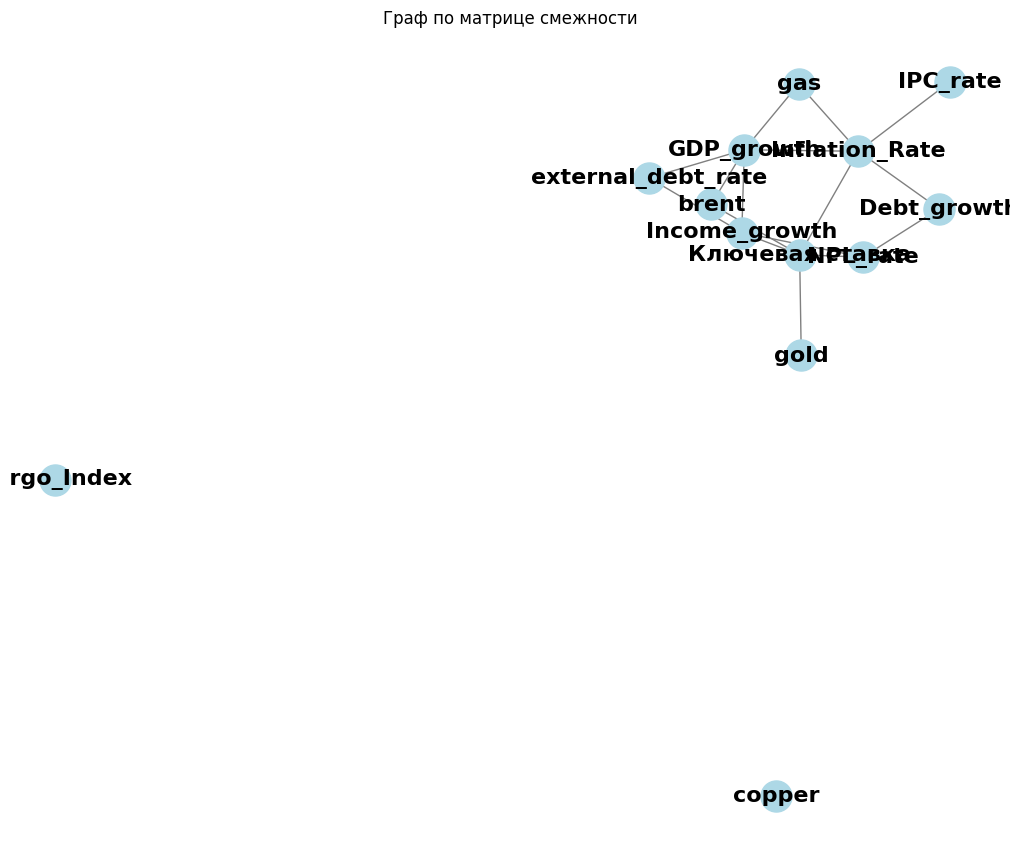

In [423]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Преобразуем в numpy array для удобства
adj_matrix = np.array(final_df)

# Создаем граф из матрицы смежности
G = nx.from_numpy_array(adj_matrix)

# Создаем mapping из индексов в названия
label_mapping = {i: variables[i] for i in range(len(variables))}

# Рисуем граф
plt.figure(figsize=(10, 8))
nx.draw(G, 
        labels=label_mapping,
        with_labels=True, 
        node_color='lightblue', 
        node_size=500, 
        font_size=16, 
        font_weight='bold',
        edge_color='gray')
plt.title("Граф по матрице смежности")
plt.show()

## 5.2. Ориентация ребер

In [424]:
def orient_edges(graph, data, variables, time_order=None, verbose=False):
    """
    Ориентация рёбер в графе на основе временного порядка и v-структур
    
    Parameters:
    -----------
    graph : np.array
        Неориентированный граф (матрица смежности)
    data : DataFrame
        Данные (не используется, оставлено для совместимости)
    variables : list
        Список переменных
    time_order : dict or None
        Словарь {variable: order}, где order - временной приоритет (меньше = раньше)
    verbose : bool
        Выводить ли детальную информацию
    
    Returns:
    --------
    oriented_graph : np.array
        Ориентированный граф
    """
    n = len(variables)
    oriented_graph = graph.copy()
    
    changes = {'temporal': 0, 'vstructure': 0}
    
    # 1. Временная ориентация
    if time_order is not None:
        if verbose:
            print("Применяем временную ориентацию...")
        
        # Проверяем что все переменные есть в time_order
        missing_vars = [v for v in variables if v not in time_order]
        if missing_vars:
            print(f"⚠ Предупреждение: переменные отсутствуют в time_order: {missing_vars}")
            print("  Они будут пропущены при временной ориентации")
        
        for i in range(n):
            for j in range(n):
                # Проверяем что обе переменные есть в time_order
                if variables[i] not in time_order or variables[j] not in time_order:
                    continue
                
                # Если есть ребро в обе стороны (неориентированное)
                if oriented_graph[i, j] == 1 and oriented_graph[j, i] == 1:
                    # Если i происходит раньше j по времени, то i -> j
                    if time_order[variables[i]] < time_order[variables[j]]:
                        oriented_graph[j, i] = 0  # удаляем обратное ребро j -> i
                        changes['temporal'] += 1
                        if verbose:
                            print(f"  {variables[i]} → {variables[j]} (порядок: {time_order[variables[i]]} < {time_order[variables[j]]})")
                    elif time_order[variables[i]] > time_order[variables[j]]:
                        oriented_graph[i, j] = 0  # удаляем i -> j
                        changes['temporal'] += 1
                        if verbose:
                            print(f"  {variables[j]} → {variables[i]} (порядок: {time_order[variables[j]]} < {time_order[variables[i]]})")
    
    # 2. Ориентация на основе v-структур (правило Мeek R1)
    # Если i -> k и k - j (неориентированное), и i, j не смежны, то k -> j
    if verbose:
        print("\nПрименяем правила ориентации v-структур...")
    
    max_iterations = 10
    iteration = 0
    
    while iteration < max_iterations:
        changed = False
        
        for k in range(n):
            # Ищем родителей k (i -> k)
            parents = [i for i in range(n) 
                      if oriented_graph[i, k] == 1 and oriented_graph[k, i] == 0]
            
            # Ищем неориентированных соседей k (k - j)
            undirected_neighbors = [j for j in range(n)
                                   if oriented_graph[k, j] == 1 and oriented_graph[j, k] == 1]
            
            # Проверяем v-структуры
            for i in parents:
                for j in undirected_neighbors:
                    # Если i и j не смежны, то это v-структура i -> k <- j
                    if oriented_graph[i, j] == 0 and oriented_graph[j, i] == 0:
                        # Ориентируем k -> j (точнее, это должно быть k <- j для v-структуры)
                        # Но согласно правилу Meek R1: если i -> k - j и i,j не смежны, то k -> j
                        oriented_graph[j, k] = 0  # удаляем j -> k
                        changes['vstructure'] += 1
                        changed = True
                        if verbose:
                            print(f"  V-структура: {variables[i]} → {variables[k]} ← {variables[j]}")
        
        if not changed:
            break
        iteration += 1
    
    if verbose:
        print(f"\nРезультаты ориентации:")
        print(f"  Временная ориентация: {changes['temporal']} рёбер")
        print(f"  V-структуры: {changes['vstructure']} рёбер")
        print(f"  Итераций для v-структур: {iteration}")
        
        # Статистика финального графа
        n_directed = 0
        n_undirected = 0
        for i in range(n):
            for j in range(i+1, n):
                if oriented_graph[i, j] == 1 and oriented_graph[j, i] == 0:
                    n_directed += 1
                elif oriented_graph[i, j] == 0 and oriented_graph[j, i] == 1:
                    n_directed += 1
                elif oriented_graph[i, j] == 1 and oriented_graph[j, i] == 1:
                    n_undirected += 1
        
        print(f"\nФинальная статистика:")
        print(f"  Ориентированных рёбер: {n_directed}")
        print(f"  Неориентированных рёбер: {n_undirected}")
    
    return oriented_graph

**ПРАВИЛЬНЫЙ ВРЕМЕННОЙ ПОРЯДОК** 

Для NPL прогнозирования в российском контексте:
1. Внешние факторы (commodity prices) - самые быстрые
2. Макроэкономика (GDP, инфляция, ставка)
3. Рынок труда (безработица, доходы)
4. Целевая переменная (NPL) - последняя

In [425]:
time_order = {
    # Уровень 0: Commodity prices (внешние шоки, влияют быстро)
    'brent': 0,
    'gas': 0,
    'copper': 0,
    'gold': 0,
    
    # Уровень 1: Основные макропоказатели
    'GDP_growth': 1,
    'external_debt_rate': 1,
    'Cargo_Index': 1,
    'Debt_growth': 1, 
    'IPC_rate': 1,  # индекс промпроизводства
    
    # Уровень 2: Монетарная политика (ЦБ реагирует на экономику)
    'Inflation_Rate': 2,
    'Ключевая ставка': 2,  
    
    # Уровень 3: Рынок труда и доходы (запаздывают от GDP)
    'Unemployment_rate': 3,
    'Income_growth': 3,
    
    # Уровень 4: Целевая переменная (самая последняя!)
    'NPL_rate': 4
}

In [426]:
# Проверка что все переменные покрыты
missing = set(variables) - set(time_order.keys())
if missing:
    print(f"\nОШИБКА: Переменные отсутствуют в time_order: {missing}")
else:
    print("\n✓ Все переменные покрыты временным порядком")


✓ Все переменные покрыты временным порядком


**Применение**

In [427]:
# Выбираем какой граф ориентировать
#graph_to_orient = causal_graph_ges 
graph_to_orient = final_graph

oriented_graph = orient_edges(
    graph_to_orient, 
    full_df, 
    variables, 
    time_order=time_order,
    verbose=True
)

Применяем временную ориентацию...
  Ключевая ставка → Income_growth (порядок: 2 < 3)
  IPC_rate → Inflation_Rate (порядок: 1 < 2)
  brent → GDP_growth (порядок: 0 < 1)

Применяем правила ориентации v-структур...
  V-структура: brent → Ключевая ставка ← Inflation_Rate
  V-структура: gold → Ключевая ставка ← Inflation_Rate

Результаты ориентации:
  Временная ориентация: 3 рёбер
  V-структуры: 2 рёбер
  Итераций для v-структур: 1

Финальная статистика:
  Ориентированных рёбер: 16
  Неориентированных рёбер: 0


**Ориентированный граф**

In [428]:
oriented_df = pd.DataFrame(oriented_graph, index=variables, columns=variables)
oriented_df

,Ключевая ставка,Inflation_Rate,IPC_rate,GDP_growth,Income_growth,brent,gas,copper,gold,NPL_rate,Debt_growth,external_debt_rate,Cargo_Index
Ключевая ставка,0,1,0,0,1,0,0,0,0,1,0,0,0
Inflation_Rate,0,0,0,0,0,0,0,0,0,0,0,0,0
IPC_rate,0,1,0,0,0,0,0,0,0,0,0,0,0
GDP_growth,0,1,0,0,1,0,0,0,0,0,0,0,0
Income_growth,0,0,0,0,0,0,0,0,0,1,0,0,0
brent,1,0,0,1,0,0,0,0,0,0,0,0,0
gas,0,1,0,1,0,0,0,0,0,0,0,0,0
copper,0,0,0,0,0,0,0,0,0,0,0,0,0
gold,1,0,0,0,0,0,0,0,0,0,0,0,0
NPL_rate,0,0,0,0,0,0,0,0,0,0,0,0,0


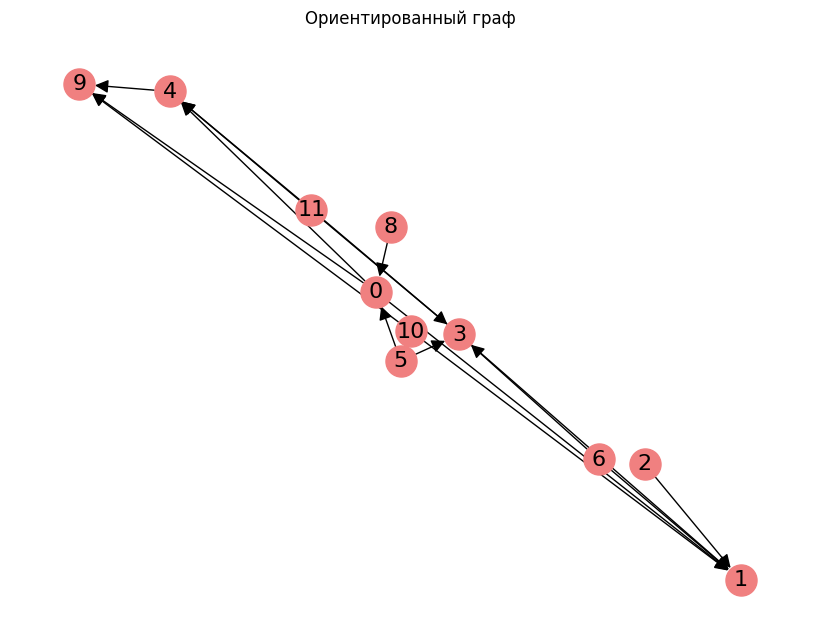

In [429]:
# Создаем ориентированный граф
directed_matrix = np.array(oriented_df)
G = nx.DiGraph()
n = len(directed_matrix)

# Добавляем ребра
for i in range(n):
    for j in range(n):
        if directed_matrix[i][j] != 0:
            G.add_edge(i, j)

# Рисуем ориентированный граф
plt.figure(figsize=(8, 6))
nx.draw(G, #labels=label_mapping,
        with_labels=True, 
        node_color='lightcoral', 
        node_size=500, 
        arrowsize=20,
        font_size=16)
plt.title("Ориентированный граф")
plt.show()

**Визуализация ориентированных рёбер**

In [430]:
directed_edges = []
undirected_edges = []

for i in range(len(variables)):
    for j in range(len(variables)):
        if oriented_graph[i, j] == 1:
            if oriented_graph[j, i] == 0:
                # Ориентированное ребро i -> j
                directed_edges.append((variables[i], variables[j]))
            elif i < j:  # избегаем дублирования неориентированных
                # Неориентированное ребро i - j
                undirected_edges.append((variables[i], variables[j]))

print(f"\nОриентированные рёбра ({len(directed_edges)} шт):")
for source, target in sorted(directed_edges):
    print(f"  {source} → {target}")

if undirected_edges:
    print(f"\nНеориентированные рёбра ({len(undirected_edges)} шт):")
    for var1, var2 in sorted(undirected_edges):
        print(f"  {var1} — {var2}")

# Рёбра направленные В NPL
print("\n" + "="*70)
print("СВЯЗИ НАПРАВЛЕННЫЕ В NPL_rate")
print("="*70)

npl_idx = variables.index('NPL_rate')
parents_of_npl = [variables[i] for i in range(len(variables))
                  if oriented_graph[i, npl_idx] == 1 and oriented_graph[npl_idx, i] == 0]

if parents_of_npl:
    print(f"\nПрямые причины NPL ({len(parents_of_npl)} шт):")
    for parent in sorted(parents_of_npl):
        print(f"  {parent} → NPL_rate")
else:
    print("\n⚠ Не обнаружено прямых причин NPL_rate")
    print("Возможные причины:")
    print("  - Граф слишком разреженный")
    print("  - Нужно ослабить alpha в PC алгоритме")
    print("  - Связи существуют только через промежуточные переменные")


Ориентированные рёбра (16 шт):
  Debt_growth → Inflation_Rate
  Debt_growth → NPL_rate
  GDP_growth → Income_growth
  GDP_growth → Inflation_Rate
  IPC_rate → Inflation_Rate
  Income_growth → NPL_rate
  brent → GDP_growth
  brent → Ключевая ставка
  external_debt_rate → GDP_growth
  external_debt_rate → Income_growth
  gas → GDP_growth
  gas → Inflation_Rate
  gold → Ключевая ставка
  Ключевая ставка → Income_growth
  Ключевая ставка → Inflation_Rate
  Ключевая ставка → NPL_rate

СВЯЗИ НАПРАВЛЕННЫЕ В NPL_rate

Прямые причины NPL (3 шт):
  Debt_growth → NPL_rate
  Income_growth → NPL_rate
  Ключевая ставка → NPL_rate


# 6. Этап 4: Оценка силы причинных связей
## 6.1. Линейная структурная модель

In [431]:
from sklearn.linear_model import LassoCV, RidgeCV
import networkx as nx

def estimate_causal_effects(data, graph, variables):
    """
    Оценка силы причинных эффектов с помощью линейной регрессии
    """
    n = len(variables)
    causal_effects = np.zeros((n, n))
    
    # Топологическая сортировка для определения порядка оценки
    G = nx.DiGraph()
    for i in range(n):
        G.add_node(i)
    for i in range(n):
        for j in range(n):
            if graph[i, j] == 1:
                G.add_edge(i, j)
    
    try:
        topo_order = list(nx.topological_sort(G))
    except:
        # Если граф содержит циклы, используем обычный порядок
        topo_order = list(range(n))
    
    # Оцениваем эффекты в топологическом порядке
    for j in topo_order:
        y = data[variables[j]].values
        parents = [i for i in range(n) if graph[i, j] == 1]
        
        if len(parents) > 0:
            X = data[[variables[i] for i in parents]].values
            
            alphas = np.logspace(-3, 3, 50)  # диапазон альфа от 0.001 до 1000
            model = RidgeCV(alphas=alphas, cv=5)
            model.fit(X, y)
            
            for idx, parent in enumerate(parents):
                causal_effects[parent, j] = model.coef_[idx]
    
    return causal_effects

# Оцениваем силу связей
causal_effects = estimate_causal_effects(data_scaled, oriented_graph, variables)

print("Матрица причинных эффектов:")
effects_df = pd.DataFrame(causal_effects, index=variables, columns=variables)
effects_df

Матрица причинных эффектов:


,Ключевая ставка,Inflation_Rate,IPC_rate,GDP_growth,Income_growth,brent,gas,copper,gold,NPL_rate,Debt_growth,external_debt_rate,Cargo_Index
Ключевая ставка,0.000000,0.220961,0.0,0.000000,0.070075,0.0,0.0,0.0,0.0,-0.000032,0.0,0.0,0.0
Inflation_Rate,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
IPC_rate,0.000000,0.142160,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
GDP_growth,0.000000,0.148355,0.0,0.000000,0.066033,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
Income_growth,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,-0.012397,0.0,0.0,0.0
brent,-0.026232,0.000000,0.0,0.255177,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
gas,0.000000,0.088562,0.0,0.029354,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
copper,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
gold,0.054731,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
NPL_rate,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


## 6.2. Нелинейные причинные эффекты

In [432]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

def estimate_nonlinear_effects(data, graph, variables):
    """
    Оценка нелинейных причинных эффектов
    """
    n = len(variables)
    nonlinear_importance = np.zeros((n, n))
    
    for j in range(n):
        y = data[variables[j]].values
        parents = [i for i in range(n) if graph[i, j] == 1]
        
        if len(parents) > 0:
            X = data[[variables[i] for i in parents]].values
            
            # Используем градиентный бустинг для нелинейностей
            model = GradientBoostingRegressor(n_estimators=100, 
                                             max_depth=3,
                                             random_state=42)
            model.fit(X, y)
            
            # Оцениваем важность через permutation
            perm_importance = permutation_importance(model, X, y, 
                                                    n_repeats=10,
                                                    random_state=42)
            
            for idx, parent in enumerate(parents):
                nonlinear_importance[parent, j] = perm_importance.importances_mean[idx]
    
    return nonlinear_importance

# Оцениваем нелинейные эффекты
nonlinear_effects = estimate_nonlinear_effects(full_df, oriented_graph, variables)

print("Матрица нелинейных эффектов:")
nl_effects_df = pd.DataFrame(nonlinear_effects, index=variables, columns=variables)
print(nl_effects_df)

Матрица нелинейных эффектов:
                    Ключевая ставка  Inflation_Rate  IPC_rate  GDP_growth  \
Ключевая ставка            0.000000        0.745509       0.0    0.000000   
Inflation_Rate             0.000000        0.000000       0.0    0.000000   
IPC_rate                   0.000000        0.116355       0.0    0.000000   
GDP_growth                 0.000000        0.278123       0.0    0.000000   
Income_growth              0.000000        0.000000       0.0    0.000000   
brent                      0.743907        0.000000       0.0    0.786267   
gas                        0.000000        0.163392       0.0    0.270268   
copper                     0.000000        0.000000       0.0    0.000000   
gold                       1.249402        0.000000       0.0    0.000000   
NPL_rate                   0.000000        0.000000       0.0    0.000000   
Debt_growth                0.000000        0.237348       0.0    0.000000   
external_debt_rate         0.000000        0.00

# 7. Этап 5: Валидация причинного графа

## 7.1. Тестирование на разных временных периодах

In [433]:
def temporal_stability_test(data, graph, variables, n_splits=5):
    """
    Проверка стабильности причинной структуры во времени
    """
    split_size = len(data) // n_splits
    stability_scores = []
    
    for i in range(n_splits):
        start_idx = i * split_size
        end_idx = (i + 1) * split_size if i < n_splits - 1 else len(data)
        
        data_split = data.iloc[start_idx:end_idx]
        
        # Переоцениваем граф на подвыборке
        graph_split, _ = discover_causal_structure_pc(data_split, variables, alpha=0.05)
        
        # Вычисляем схожесть графов (structural Hamming distance)
        shd = np.sum(np.abs(graph - graph_split))
        stability_scores.append(shd)
    
    return stability_scores

# Проверяем стабильность
stability = temporal_stability_test(data_scaled, oriented_graph, variables)

print(f"Оценки стабильности структуры (SHD): {stability}")
print(f"Средняя: {np.mean(stability):.2f}, Стд: {np.std(stability):.2f}")

Размерность данных: (35, 13)
Тип данных: float64


  0%|          | 0/13 [00:00<?, ?it/s]

Depth=11, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 2058.52it/s]


Размерность данных: (35, 13)
Тип данных: float64


Depth=2, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 1482.17it/s]


...

Размерность данных: (35, 13)
Тип данных: float64


Depth=2, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 1206.43it/s]


Размерность данных: (35, 13)
Тип данных: float64


Depth=2, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 1484.99it/s]

Оценки стабильности структуры (SHD): [np.float64(40.0), np.float64(27.0), np.float64(24.0), np.float64(25.0), np.float64(22.0)]
Средняя: 27.60, Стд: 6.41


# 8. Этап 6: Визуализация и интерпретация
## 8.1. Визуализация графа

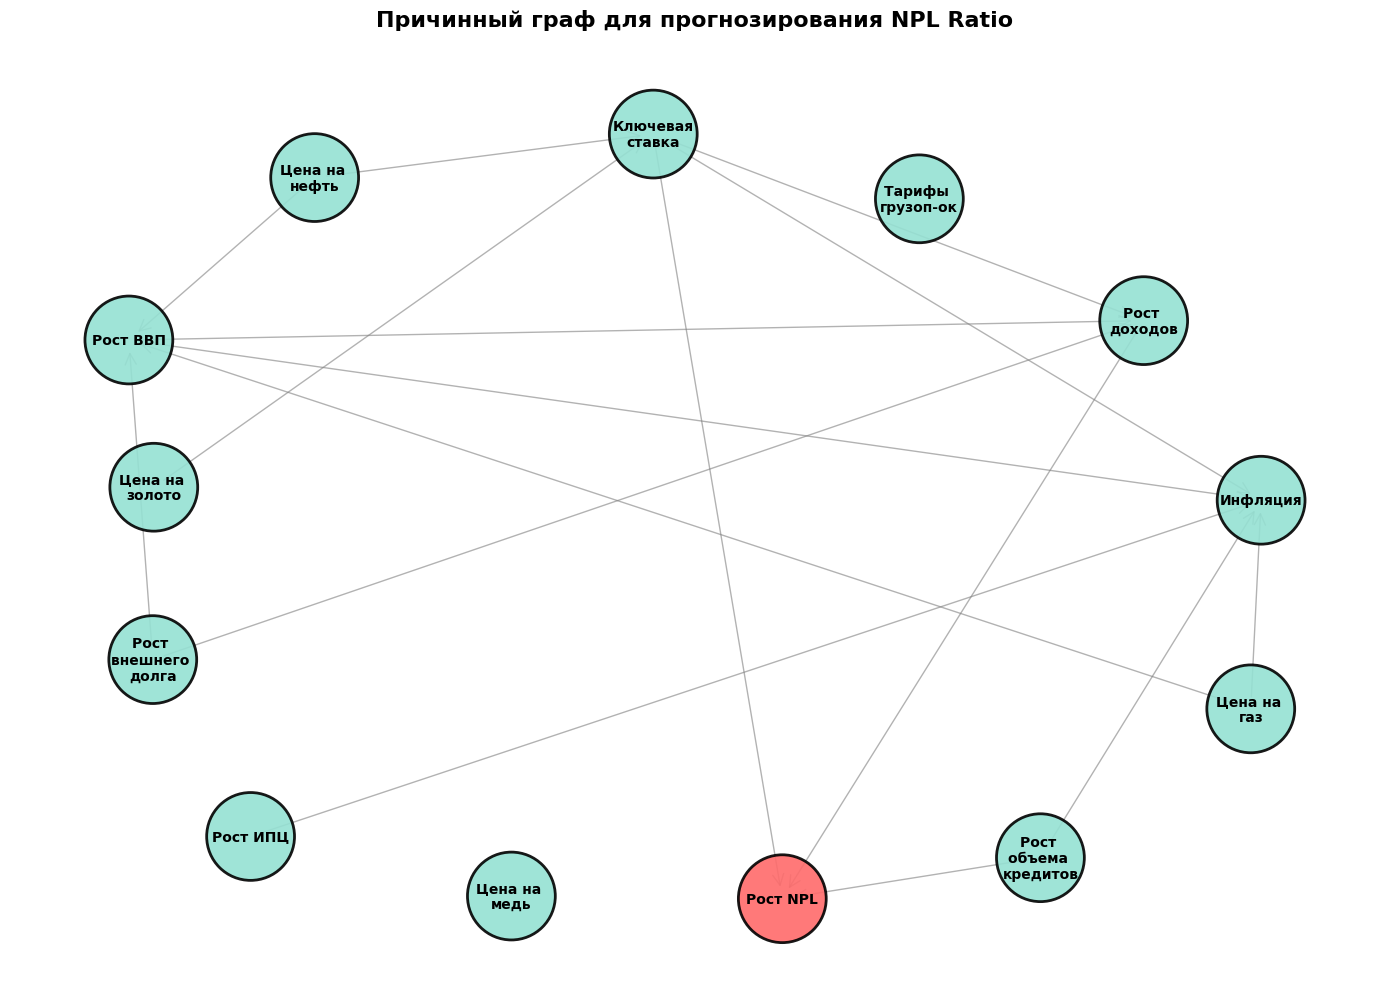

In [434]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_causal_graph(graph, variables, causal_effects=None, 
                          save_path='causal_graph_npl.png'):
    """
    Визуализация причинного графа
    """
    # Создаем направленный граф
    G = nx.DiGraph()
    
    # Добавляем узлы
    for var in variables:
        G.add_node(var)
    
    # Добавляем ребра с весами
    n = len(variables)
    for i in range(n):
        for j in range(n):
            if graph[i, j] == 1:
                weight = causal_effects[i, j] if causal_effects is not None else 1
                G.add_edge(variables[i], variables[j], weight=abs(weight))
    
    # Настройка визуализации
    plt.figure(figsize=(14, 10))
    
    # Иерархическое расположение (по уровням причинности)
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Цвета узлов по типу
    node_colors = []
    for var in variables:
        if var == 'NPL_rate':
            node_colors.append('#ff6b6b')  # красный для целевой переменной
        else:
            node_colors.append('#95e1d3')  # зеленый для банковских

    # Рисуем ребра с толщиной пропорциональной силе связи
    if causal_effects is not None:
        edges = G.edges()
        weights = [G[u][v]['weight'] for u, v in edges]
        max_weight = max(weights) if weights else 1
        edge_widths = [3 * w / max_weight for w in weights]
    else:
        edge_widths = [2] * len(G.edges())
    
    nx.draw_networkx_edges(G, pos,
                          #width=edge_widths,
                          alpha=0.6,
                          edge_color='gray',
                          arrows=True,
                          arrowsize=20,
                          arrowstyle='->')

    # Рисуем узлы
    nx.draw_networkx_nodes(G, pos, 
                          node_color=node_colors,
                          node_size=4000,
                          alpha=0.9,
                          edgecolors='black',
                          linewidths=2)
    
    # СПОСОБ 1: Словарь с пользовательскими подписями
    custom_labels = {
        'NPL_rate': 'Рост NPL',
        'GDP_growth': 'Рост ВВП',
        'Inflation_Rate': 'Инфляция',
        'brent': 'Цена на \nнефть',
        'Ключевая ставка': 'Ключевая\nставка',
        'gas': 'Цена на \nгаз',
        'IPC_rate': 'Рост ИПЦ',
        'copper': 'Цена на \nмедь',
        'gold': 'Цена на \nзолото',
        'Debt_growth': 'Рост \nобъема \nкредитов',
        'Income_growth': 'Рост \nдоходов',
        'external_debt_rate': 'Рост \nвнешнего \nдолга',
        'Cargo_Index': 'Тарифы \nгрузоп-ок'
    }
    
    # Если какие-то переменные не в словаре, используем оригинальные имена
    labels = {var: custom_labels.get(var, var) for var in variables}
    
    # Рисуем подписи с пользовательскими текстами
    nx.draw_networkx_labels(G, pos,
                           labels=labels,  # передаем словарь с подписями
                           font_size=10,
                           font_weight='bold',
                           font_family='sans-serif')
    
    # Легенда
    from matplotlib.patches import Patch
    """
    legend_elements = [
        Patch(facecolor='#ff6b6b', label='Target (NPL)'),
        Patch(facecolor='#4ecdc4', label='Macro factors'),
        Patch(facecolor='#95e1d3', label='Bank factors')
    ]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=10)"""
    
    plt.title('Причинный граф для прогнозирования NPL Ratio', 
             fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Визуализируем граф
visualize_causal_graph(oriented_graph, variables, causal_effects)

In [416]:
oriented_graph

array([[0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [417]:
for i, var_i in enumerate(variables):
    for j, var_j in enumerate(variables):
        if oriented_graph[i][j] == 1:
            print(f'- {var_i} vs {var_j}')

- Ключевая ставка vs Inflation_Rate
- Ключевая ставка vs Income_growth
- Ключевая ставка vs NPL_rate
- IPC_rate vs Inflation_Rate
- GDP_growth vs Inflation_Rate
- GDP_growth vs Income_growth
- Income_growth vs NPL_rate
- brent vs Ключевая ставка
- brent vs GDP_growth
- brent vs gas
- brent vs copper
- gas vs Inflation_Rate
- gas vs GDP_growth
- copper vs brent
- copper vs gold
- gold vs Ключевая ставка
- gold vs copper
- Debt_growth vs Inflation_Rate
- Debt_growth vs NPL_rate
- external_debt_rate vs GDP_growth
- external_debt_rate vs Income_growth
